In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist
import cv2
from scipy import ndimage
import albumentations as A
import random
import warnings
warnings.filterwarnings('ignore')

In [68]:
# Load a sample dataset - we'll use both a tabular dataset and an image dataset
# For tabular data, let's use the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [69]:
# Basic Exploration
print(f"Dataset shape: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (891, 12)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [70]:
# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna('Unknown', inplace=True)

# ----- FEATURE ENGINEERING FOR TABULAR DATA -----

In [71]:
# 1. Extract title from name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

In [72]:
# 2. Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 for the passenger themselves

In [73]:
# 3. Create is_alone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

In [74]:
# 4. Create fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [75]:
# 5. Bin age into categories
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 65, 100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

In [76]:
# 6. Bin fare into categories
df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])


In [77]:
# 7. Create deck from cabin
df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [78]:
# 8. Interaction features
df['Family_Survival'] = df['FamilySize'] * df['Survived']


In [79]:
# 9. Categorical encodings
# One-hot encoding for categorical features
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

In [80]:
# Combine with numerical features
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson']
X = pd.concat([df[numerical_features], df_encoded], axis=1)
y = df['Survived']

In [81]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [82]:
# Feature selection using SelectKBest
selector = SelectKBest(f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

In [83]:

# Display top features
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})
top_features = feature_scores.sort_values('Score', ascending=False).head(15)
print("\nTop 15 features:")
print(top_features)


Top 15 features:
              Feature       Score
12           Title_Mr  383.945495
8            Sex_male  372.405724
13          Title_Mrs  117.749079
7              Pclass  115.031272
11         Title_Miss  112.860827
26             Deck_U   99.253142
3                Fare   63.030764
20  FareBin_Very High   51.329338
6       FarePerPerson   45.910184
5             IsAlone   38.353651
22             Deck_D   20.663186
10         Embarked_S   20.374460
23             Deck_E   19.179221
21             Deck_C   11.841661
18     FareBin_Medium    8.208162


In [84]:
# Train a model with the engineered features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.25, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [85]:
# Evaluate the model
y_pred = model.predict(X_test)
print("\nModel accuracy with engineered features:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Model accuracy with engineered features: 0.8116591928251121

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



# ----- ADVANCED FEATURE ENGINEERING -----

In [86]:
# 1. Polynomial features (example with a simple subset)
from sklearn.preprocessing import PolynomialFeatures

In [87]:
# Just using Age and Fare for demonstration
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_data = poly_features.fit_transform(df[['Age', 'Fare']].fillna(0))

In [88]:
# Display polynomial feature names
feature_names = poly_features.get_feature_names_out(['Age', 'Fare'])
print("\nPolynomial features generated:")
print(feature_names)


Polynomial features generated:
['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


In [89]:
# 2. PCA for dimensionality reduction
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

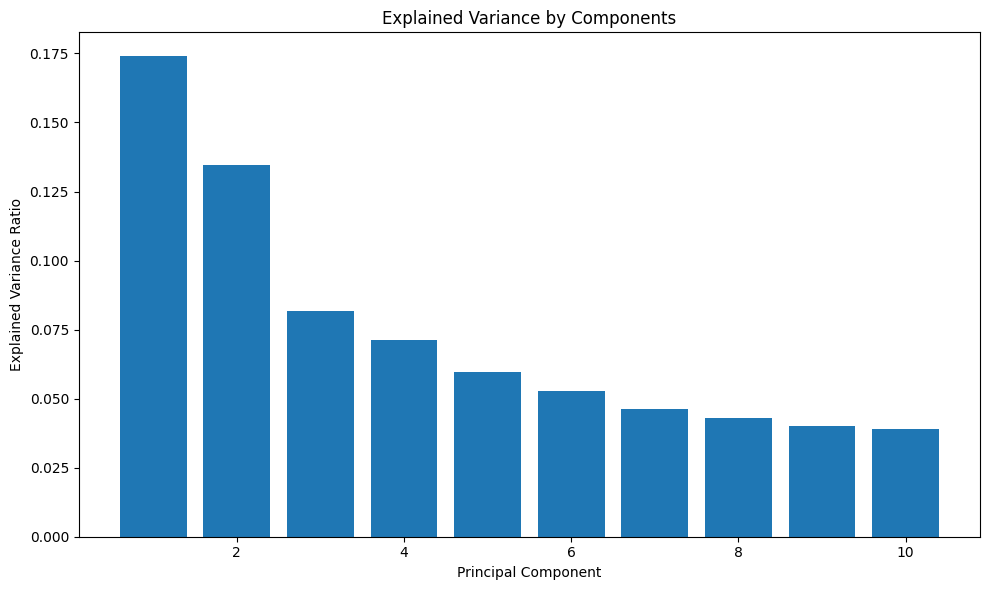

In [90]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Components')
plt.tight_layout()
plt.show()

In [91]:
# Print cumulative explained variance
print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Cumulative explained variance:
[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


# ----- DATA AUGMENTATION FOR IMAGES -----

In [92]:
# Load MNIST dataset for image augmentation examples
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

In [93]:
# Normalize the data
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

In [94]:
# Expand dimensions for Keras (add channel dimension)
X_train_img = X_train_img.reshape(-1, 28, 28, 1)
X_test_img = X_test_img.reshape(-1, 28, 28, 1)

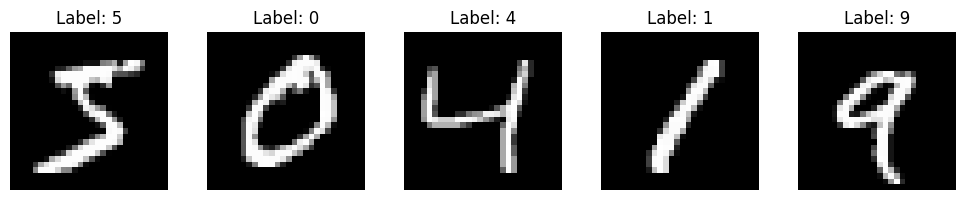

In [95]:
# Display some original images
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()


In [96]:
# ----- 1. BASIC IMAGE AUGMENTATION WITH KERAS -----

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [97]:
# Visualize augmented images
augmented_images = []
for x_batch in datagen.flow(X_train_img[:5], batch_size=1, shuffle=False):
    augmented_images.append(x_batch[0])
    if len(augmented_images) >= 15:  # Generate 3 augmented versions of each of the 5 images
        break

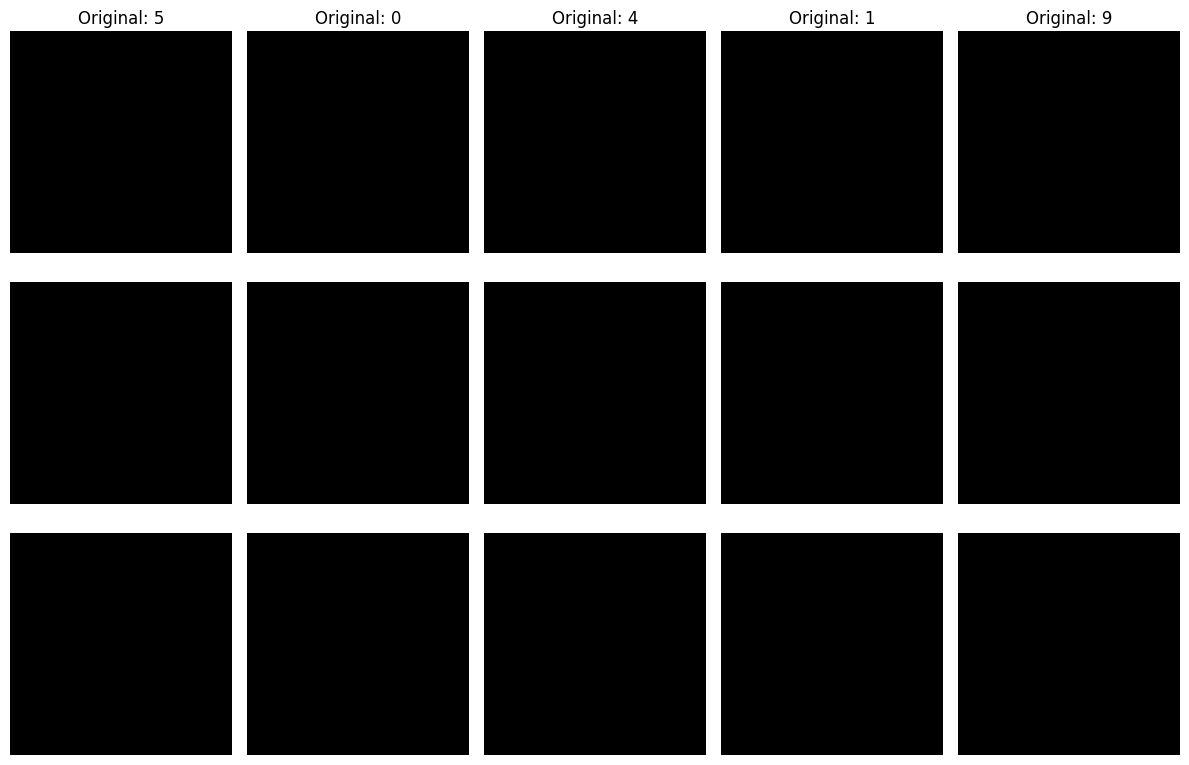

In [98]:
# Display augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i < 5:
        plt.title(f"Original: {y_train_img[i]}")
plt.tight_layout()
plt.show()

In [99]:
# ----- 2. AUGMENTATION WITH TF.IMAGE -----
def augment_with_tf(image):
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Random rotation
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Ensure values are still between 0 and 1
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

In [100]:
# Apply tf.image augmentation to a few images
augmented_tf_images = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = augment_with_tf(X_train_img[i]).numpy()
        augmented_tf_images.append(aug_img)

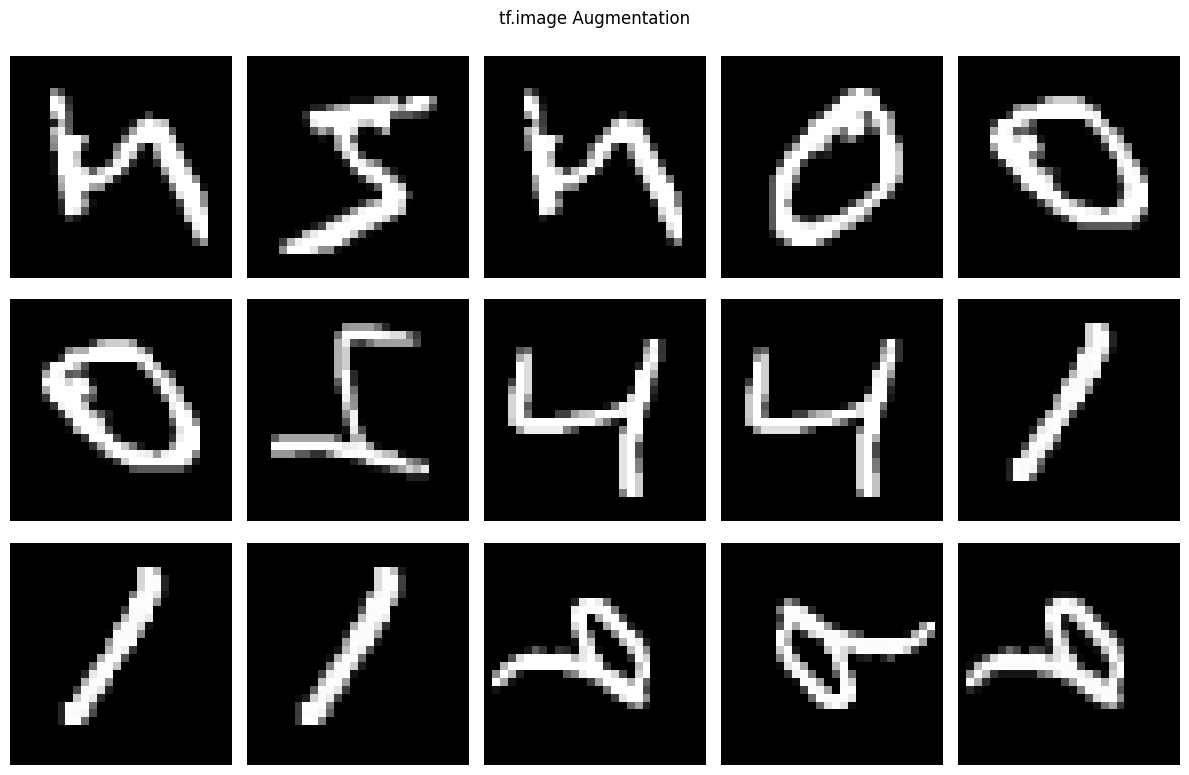

In [101]:
# Display tf.image augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(augmented_tf_images):
    plt.subplot(3, 5, i+1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.suptitle('tf.image Augmentation')
plt.tight_layout()
plt.show()

In [102]:
# ----- 3. AUGMENTATION WITH OPENCV -----

def opencv_augment(image):
    # Convert to 0-255 range and uint8 for OpenCV
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Choose a random augmentation
    choice = np.random.choice(['rotate', 'blur', 'zoom', 'original'])

    if choice == 'rotate':
        # Random rotation
        angle = np.random.uniform(-15, 15)
        return ndimage.rotate(image, angle, reshape=False)

    elif choice == 'blur':
        # Add blur
        return cv2.GaussianBlur(image, (3, 3), 0)

    elif choice == 'zoom':
        # Random zoom
        zoom_factor = np.random.uniform(0.8, 1.2)
        height, width = image.shape

        # Compute new dimensions
        new_height = int(height * zoom_factor)
        new_width = int(width * zoom_factor)

        if zoom_factor < 1:  # Zoom out
            # Crop the image
            y_start = (height - new_height) // 2
            x_start = (width - new_width) // 2
            cropped = image[y_start:y_start+new_height, x_start:x_start+new_width]
            # Resize back to original size
            return cv2.resize(cropped, (width, height))
        else:  # Zoom in
            # Resize
            resized = cv2.resize(image, (new_width, new_height))
            # Crop to original size
            y_start = (new_height - height) // 2
            x_start = (new_width - width) // 2
            return resized[y_start:y_start+height, x_start:x_start+width]

    else:
        # Return original
        return image

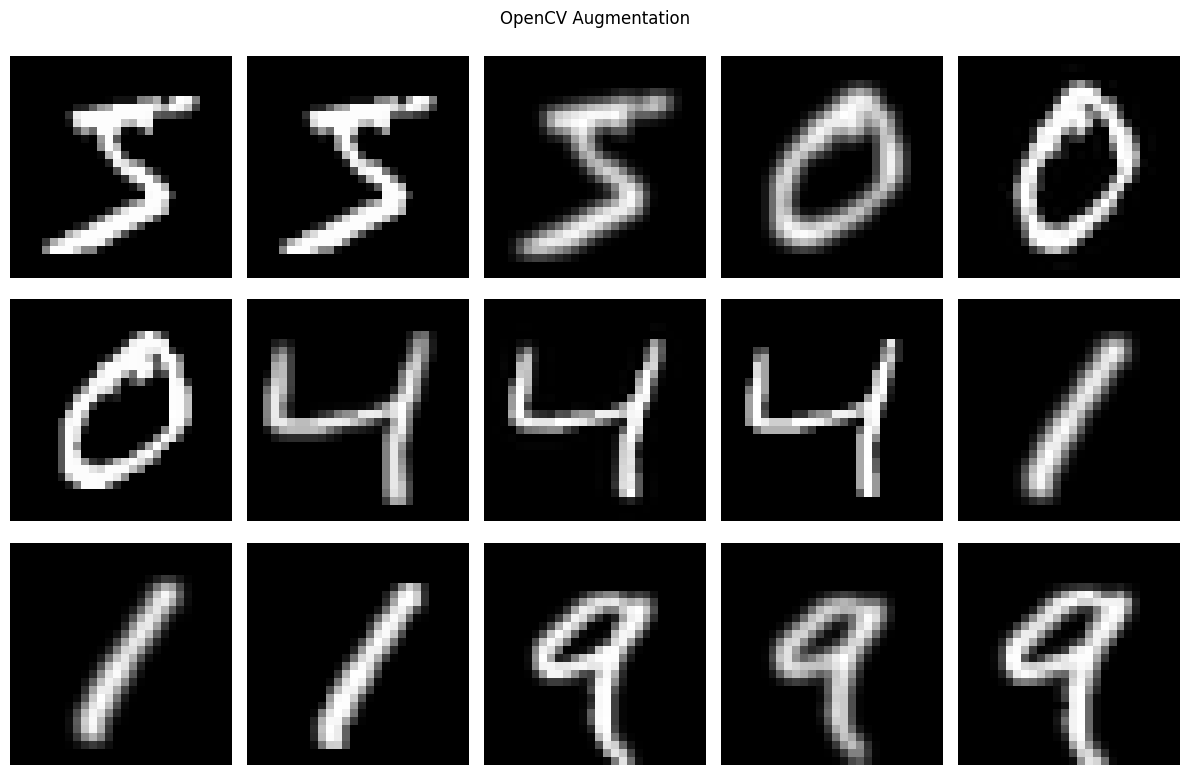

In [103]:

# Apply OpenCV augmentation
opencv_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = opencv_augment(X_train_img[i])
        # Normalize back to 0-1
        aug_img = aug_img.astype(np.float32) / 255.0
        opencv_augmented.append(aug_img)

# Display OpenCV augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(opencv_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('OpenCV Augmentation')
plt.tight_layout()
plt.show()

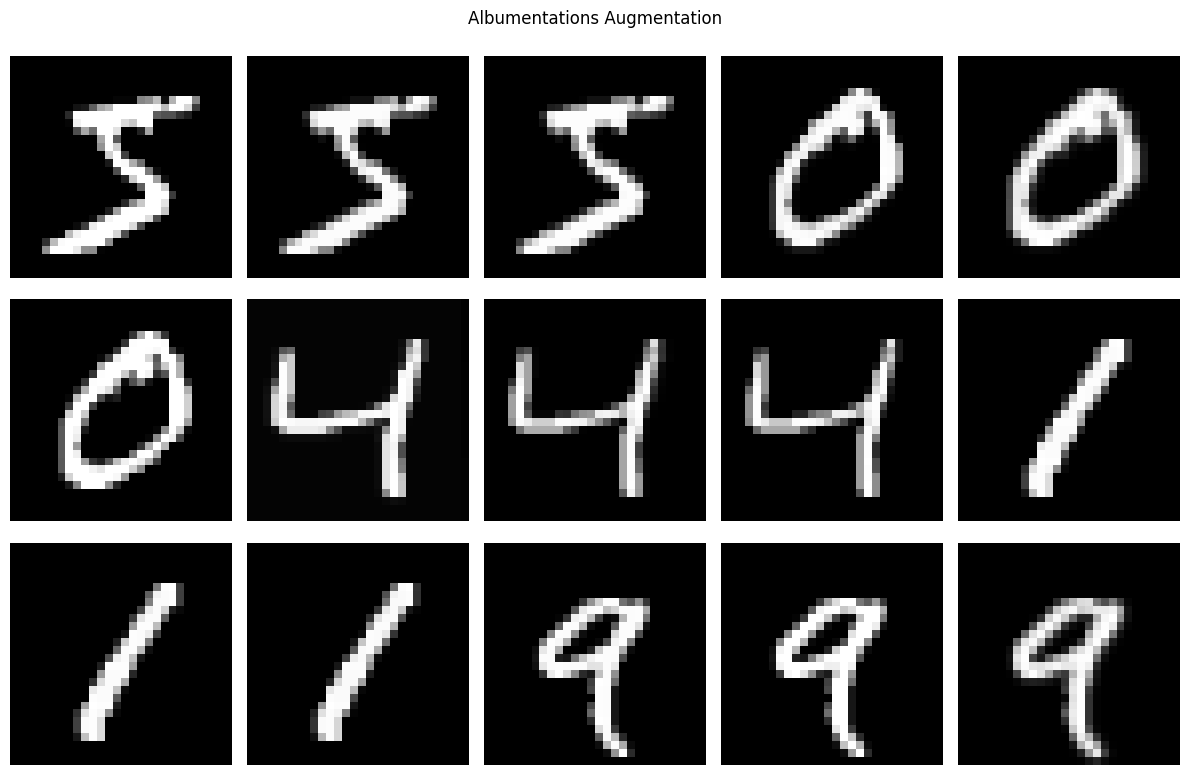

In [104]:
# ----- 4. AUGMENTATION WITH ALBUMENTATIONS -----

def apply_albumentation(image):
    # Convert to 0-255 range and uint8 for Albumentations
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Define transformation pipeline
    transform = A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.RandomGamma(p=0.8),
        ], p=0.5),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.5),
    ])

    # Apply transformation
    augmented = transform(image=image)['image']

    # Normalize back to 0-1
    return augmented.astype(np.float32) / 255.0

# Apply Albumentations
albu_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = apply_albumentation(X_train_img[i])
        albu_augmented.append(aug_img)

# Display Albumentations augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(albu_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Albumentations Augmentation')
plt.tight_layout()
plt.show()


In [105]:
# ----- 5. TEXT DATA AUGMENTATION -----

# Sample texts
texts = [
    "This is a great product, I love it!",
    "The service was terrible and I'm disappointed.",
    "I'm not sure how I feel about this experience.",
    "The food was delicious and the staff was friendly.",
    "This movie is boring and too long."
]

In [106]:
# Simple text augmentation techniques
def swap_words(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx1, idx2 = sorted(random.sample(range(len(words)), 2))
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx = random.randrange(len(words))
    return ' '.join(words[:idx] + words[idx+1:])

def insert_random_word(text, word_list=["really", "very", "somewhat", "quite", "extremely"]):
    words = text.split()
    if not words:
        return text

    idx = random.randrange(len(words))
    word_to_insert = random.choice(word_list)
    return ' '.join(words[:idx] + [word_to_insert] + words[idx:])

In [107]:
# Apply text augmentation
augmented_texts = []
for text in texts:
    augmented_texts.append(("Original", text))
    augmented_texts.append(("Word Swap", swap_words(text)))
    augmented_texts.append(("Word Deletion", delete_random_word(text)))
    augmented_texts.append(("Word Insertion", insert_random_word(text)))

In [108]:
# Display original and augmented texts
print("\nText Data Augmentation Examples:")
for aug_type, text in augmented_texts:
    print(f"{aug_type}: {text}")


Text Data Augmentation Examples:
Original: This is a great product, I love it!
Word Swap: a is This great product, I love it!
Word Deletion: This is a great product, I it!
Word Insertion: This is a great product, really I love it!
Original: The service was terrible and I'm disappointed.
Word Swap: The service terrible was and I'm disappointed.
Word Deletion: The service was terrible I'm disappointed.
Word Insertion: The extremely service was terrible and I'm disappointed.
Original: I'm not sure how I feel about this experience.
Word Swap: I not sure how I'm feel about this experience.
Word Deletion: I'm not sure how I feel about this
Word Insertion: I'm not sure how I feel about this extremely experience.
Original: The food was delicious and the staff was friendly.
Word Swap: delicious food was The and the staff was friendly.
Word Deletion: The food was and the staff was friendly.
Word Insertion: The food was delicious and the staff was very friendly.
Original: This movie is boring an

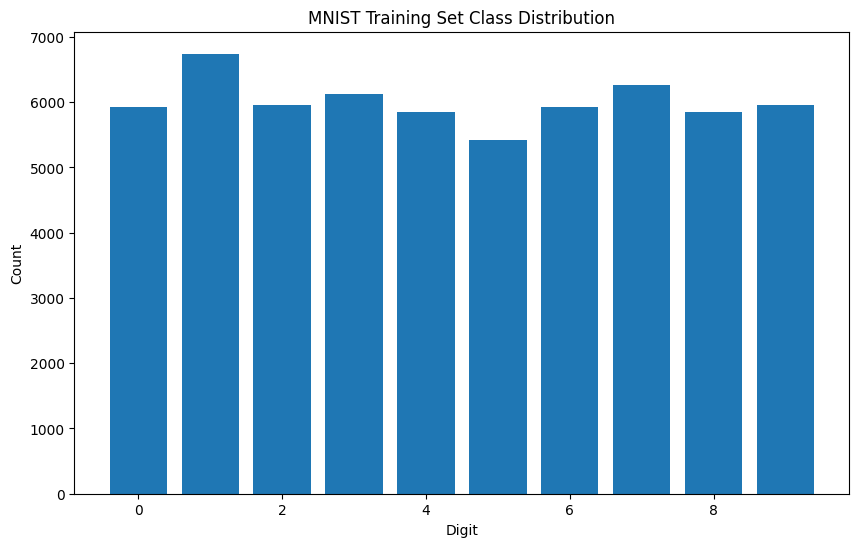

In [109]:
# ----- 6. ADVANCED APPLICATION: AUGMENT TO BALANCE CLASSES -----

# Check distribution of classes in MNIST
unique, counts = np.unique(y_train_img, return_counts=True)
class_distribution = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Training Set Class Distribution')
plt.show()

In [110]:

def augment_minority_class(X, y, target_class, num_samples):
    # Find samples of the target class
    class_indices = np.where(y == target_class)[0]
    X_class = X[class_indices]

    # If we already have enough samples, no need to augment
    if len(X_class) >= num_samples:
        return X, y

    # Number of augmentations needed
    num_augmentations = num_samples - len(X_class)

    # Create augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generate augmented images
    augmented_images = []
    augmented_labels = []

    for x_batch in datagen.flow(X_class, batch_size=1, shuffle=True):
        augmented_images.append(x_batch[0])
        augmented_labels.append(target_class)
        if len(augmented_images) >= num_augmentations:
            break

    # Convert to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    # Combine original and augmented data
    X_balanced = np.vstack([X, augmented_images])
    y_balanced = np.hstack([y, augmented_labels])

    return X_balanced, y_balanced

In [111]:
# Demonstrate balancing a subset of MNIST
# For demonstration, let's use just 100 samples per class initially
X_sample = []
y_sample = []

for digit in range(10):
    indices = np.where(y_train_img == digit)[0][:100]  # Take 100 samples of each digit
    X_sample.extend(X_train_img[indices])
    y_sample.extend(y_train_img[indices])

X_sample = np.array(X_sample)
y_sample = np.array(y_sample)

In [112]:
# Print initial distribution
unique, counts = np.unique(y_sample, return_counts=True)
print("\nInitial distribution:")
print(dict(zip(unique, counts)))


Initial distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(100), np.uint8(9): np.int64(100)}


In [113]:
# Let's artificially create an imbalance by removing some '8' samples
eight_indices = np.where(y_sample == 8)[0]
remove_indices = eight_indices[:80]  # Remove 80 samples of digit 8
mask = np.ones(len(y_sample), dtype=bool)
mask[remove_indices] = False

X_imbalanced = X_sample[mask]
y_imbalanced = y_sample[mask]


In [114]:
# Print imbalanced distribution
unique, counts = np.unique(y_imbalanced, return_counts=True)
print("\nImbalanced distribution:")
print(dict(zip(unique, counts)))



Imbalanced distribution:
{np.uint8(0): np.int64(100), np.uint8(1): np.int64(100), np.uint8(2): np.int64(100), np.uint8(3): np.int64(100), np.uint8(4): np.int64(100), np.uint8(5): np.int64(100), np.uint8(6): np.int64(100), np.uint8(7): np.int64(100), np.uint8(8): np.int64(20), np.uint8(9): np.int64(100)}


In [115]:
# Balance the dataset using augmentation
X_balanced, y_balanced = augment_minority_class(X_imbalanced, y_imbalanced, 8, 100)

# Print balanced distribution
unique, counts = np.unique(y_balanced, return_counts=True)
print("\nBalanced distribution after augmentation:")
print(dict(zip(unique, counts)))


Balanced distribution after augmentation:
{np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


In [116]:
# ----- 7. DEMONSTRATING THE EFFECT OF AUGMENTATION ON MODEL PERFORMANCE -----

# Create a simple CNN model for MNIST
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [117]:
# Train model on imbalanced data
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(X_imbalanced, y_imbalanced, epochs=5,
                                           validation_split=0.2, verbose=0)


In [118]:
# Train model on balanced data
model_balanced = create_model()
history_balanced = model_balanced.fit(X_balanced, y_balanced, epochs=5,
                                       validation_split=0.2, verbose=0)

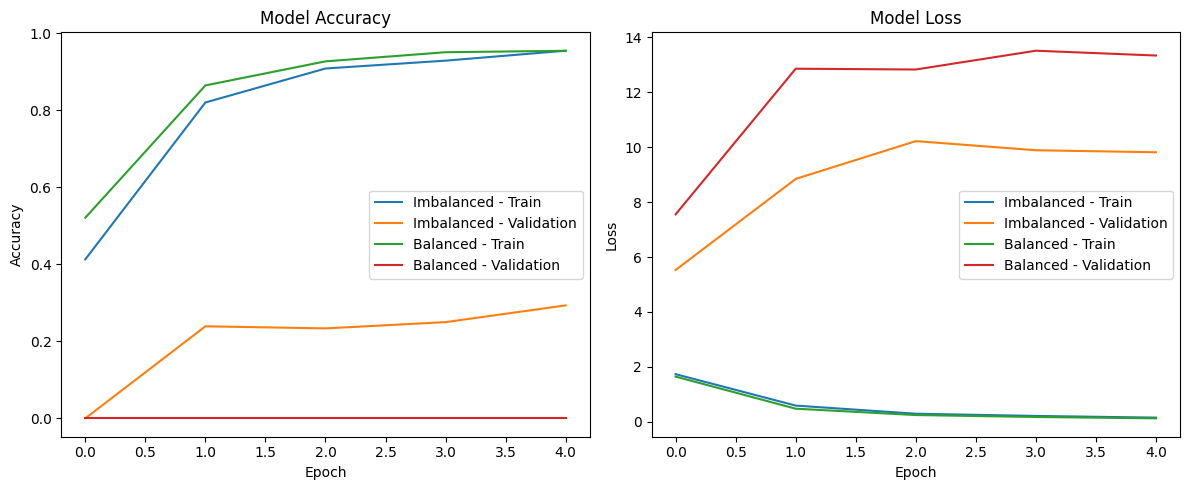

In [119]:
# Compare performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['accuracy'], label='Balanced - Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced - Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imbalanced.history['loss'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['loss'], label='Balanced - Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced - Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Excercise

In [120]:
# 1. Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# TODO: Load the Titanic dataset into `df` using pd.read_csv
# Hint: URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = None  # TODO

# TODO: Display first 5 rows and the dataset shape
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()
print(df.shape)
# TODO: Print missing value counts per column
print(df.isnull().sum())

(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [121]:
# TODO: Fill missing 'Age' with its median
df['Age'].fillna(df['Age'].median(), inplace = True)
# TODO: Fill missing 'Embarked' with its mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)
# TODO: Replace missing 'Cabin' entries with 'Unknown'
df['Cabin'].fillna('Unknown', inplace = True)


In [122]:
# 2. Missing Value Imputation

# 3.1 Extract Title from Name
# TODO: Create df['Title'] by extracting the substring before '.' in Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)


# 3.2 Group rare titles into 'Rare' and standardize variants
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

# TODO: Replace rare and variant titles accordingly
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 3.3 Family Size and IsAlone
# TODO: df['FamilySize'] = SibSp + Parch + 1

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# TODO: df['IsAlone'] = 1 where FamilySize == 1, else 0

df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3.4 Fare Per Person
# TODO: df['FarePerPerson'] = Fare / FamilySize

df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning
# TODO: Create AgeBin categories: Child (0–12), Teenager (13–18), Adult (19–65), Elderly (>65)

df['AgeBin'] = pd.cut(df['Age'], bins = [0,12,18,65,100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

# TODO: Create FareBin quantiles: Low, Medium, High, Very High

df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

# 3.6 Deck from Cabin
# TODO: df['Deck'] = first letter of Cabin; replace 'Unknown'→'U' and rare letters→'Other'

df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace('U', 'Unknown')
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [123]:
# 3. Feature Engineering

# 3.1 Extract Title from Name
# TODO: Create df['Title'] by extracting the substring before '.' in Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)

# 3.2 Group rare titles into 'Rare' and standardize variants

rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

# TODO: Replace rare and variant titles accordingly

df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 3.3 Family Size and IsAlone
# TODO: df['FamilySize'] = SibSp + Parch + 1

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# TODO: df['IsAlone'] = 1 where FamilySize == 1, else 0

df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

# 3.4 Fare Per Person
# TODO: df['FarePerPerson'] = Fare / FamilySize

df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# 3.5 Age and Fare Binning
# TODO: Create AgeBin categories: Child (0–12), Teenager (13–18), Adult (19–65), Elderly (>65)

df['AgeBin'] = pd.cut(df['Age'], bins = [0,12,18,65,100], labels=['Child', 'Teenager', 'Adult', 'Elderly'])

# TODO: Create FareBin quantiles: Low, Medium, High, Very High

df['FareBin'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])

# 3.6 Deck from Cabin
# TODO: df['Deck'] = first letter of Cabin; replace 'Unknown'→'U' and rare letters→'Other'

df['Deck'] = df['Cabin'].str[0]
df['Deck'] = df['Deck'].replace('U', 'Unknown')
df['Deck'] = df['Deck'].replace(['T', 'A', 'G'], 'Other')
df['Deck'] = df['Deck'].replace('Unknown', 'U')


In [124]:
# 4. Encoding and Scaling

# 4.1 One‑hot encode selected categorical columns using pd.get_dummies :contentReference[oaicite:11]{index=11}

categorical = ['Pclass','Sex','Embarked','Title','AgeBin','FareBin','Deck']

# TODO: df_encoded = pd.get_dummies(df[categorical], drop_first=True)

df_encoded = pd.get_dummies(df[categorical], drop_first= True)

# 4.2 Combine with numerical features

numerical = ['Age','SibSp','Parch','Fare','FamilySize','IsAlone','FarePerPerson']

# TODO: X = pd.concat([...], axis=1)

X = pd.concat([df[numerical], df_encoded], axis=1)

# TODO: y = df['Survived']

y = df['Survived']

# 4.3 Feature scaling: fit three different scalers and transform X
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# TODO: scaler_std = StandardScaler()       # :contentReference[oaicite:12]{index=12}

scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(X)

# TODO: scaler_mm  = MinMaxScaler()

scaler_mm = MinMaxScaler()

# TODO: scaler_rbv = RobustScaler()

scaler_rbv = RobustScaler()

# TODO: X_std = scaler_std.fit_transform(X)

X_std = scaler_std.fit_transform(X)

# TODO: X_mm  = scaler_mm.fit_transform(X)

X_mm = scaler_mm.fit_transform(X)

# TODO: X_rb  = scaler_rbv.fit_transform(X)
X_rb = scaler_rbv.fit_transform(X)

In [125]:
# 5. Feature Selection & Modeling

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# TODO: Use SelectKBest(f_classif, k=15) to pick top features :contentReference[oaicite:13]{index=13}

selector = SelectKBest(f_classif, k=15)

# TODO: X_sel = selector.fit_transform(X_std, y)

X_sel = selector.fit_transform(X_std, y)

# TODO: top_feats = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_}).nlargest(15,'Score')

top_feats = pd.DataFrame({'Feature' :  X.columns, 'Score': selector.scores_}).nlargest(15, 'Score')

# TODO: Split into train/test (25% test), train RandomForestClassifier, and print:

X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=0.25, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#       - Accuracy

print("Accuracy: ", accuracy_score(y_test, y_pred))

#       - Classification report

print(classification_report(y_test, y_pred))

Accuracy:  0.8116591928251121
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       134
           1       0.76      0.78      0.77        89

    accuracy                           0.81       223
   macro avg       0.80      0.81      0.80       223
weighted avg       0.81      0.81      0.81       223



['Age' 'Fare' 'Age^2' 'Age Fare' 'Fare^2']


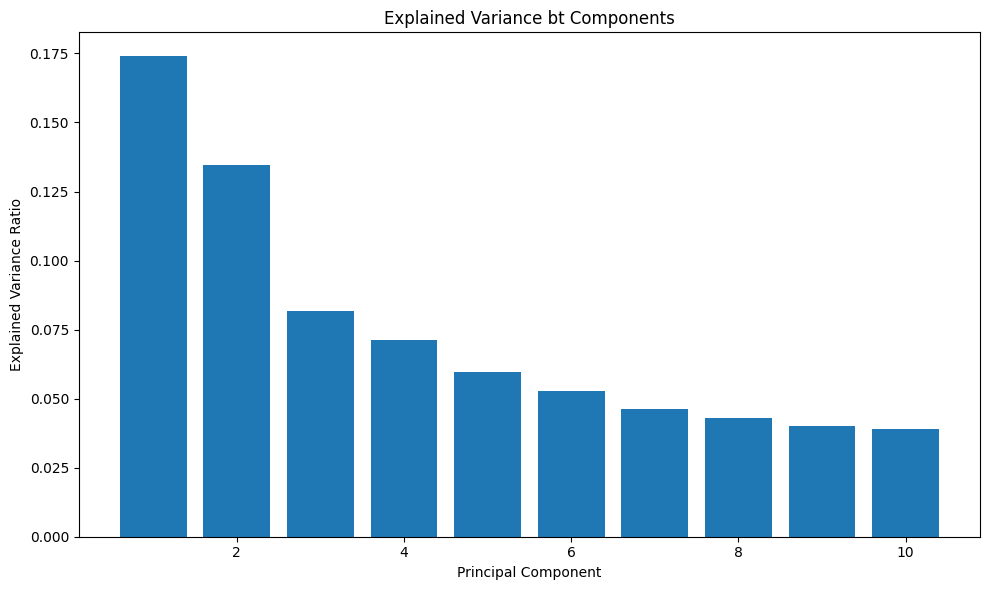


Cumulative explained variance:
[0.17394189 0.30865766 0.39044823 0.46166279 0.52117907 0.57399528
 0.62017507 0.66317021 0.70334202 0.74223912]


In [126]:
# 6. Advanced Feature Engineering

# 6.1 Polynomial Features using sklearn.preprocessing.PolynomialFeatures :contentReference[oaicite:14]{index=14}

from sklearn.preprocessing import PolynomialFeatures

# TODO: poly = PolynomialFeatures(degree=2, include_bias=False)

poly = PolynomialFeatures(degree= 2, include_bias=False)

# TODO: poly_data = poly.fit_transform(df[['Age','Fare']].fillna(0))

poly_data = poly.fit_transform(df[['Age', 'Fare']].fillna(0))

# TODO: print(poly.get_feature_names_out(['Age','Fare']))

print(poly.get_feature_names_out(['Age', 'Fare']))

# 6.2 PCA for dimensionality reduction :contentReference[oaicite:15]{index=15}

from sklearn.decomposition import PCA

# TODO: pca = PCA(n_components=10)

pca = PCA(n_components=10)

# TODO: X_pca = pca.fit_transform(X_std)

X_pca = pca.fit_transform(X_std)

# TODO: Plot explained variance ratio bar chart

plt.figure(figsize=(10,6))
plt.bar(range(1,11), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance bt Components')
plt.tight_layout()
plt.show()

# TODO: Print cumulative variance (np.cumsum)

print("\nCumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_))




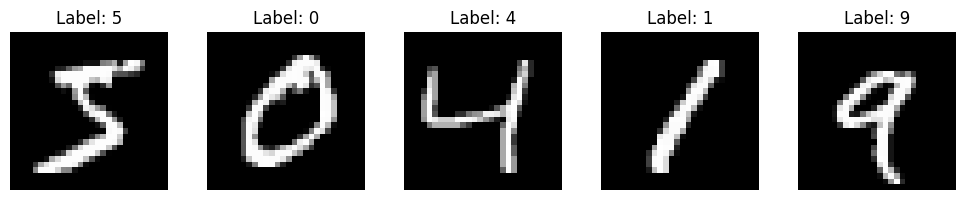

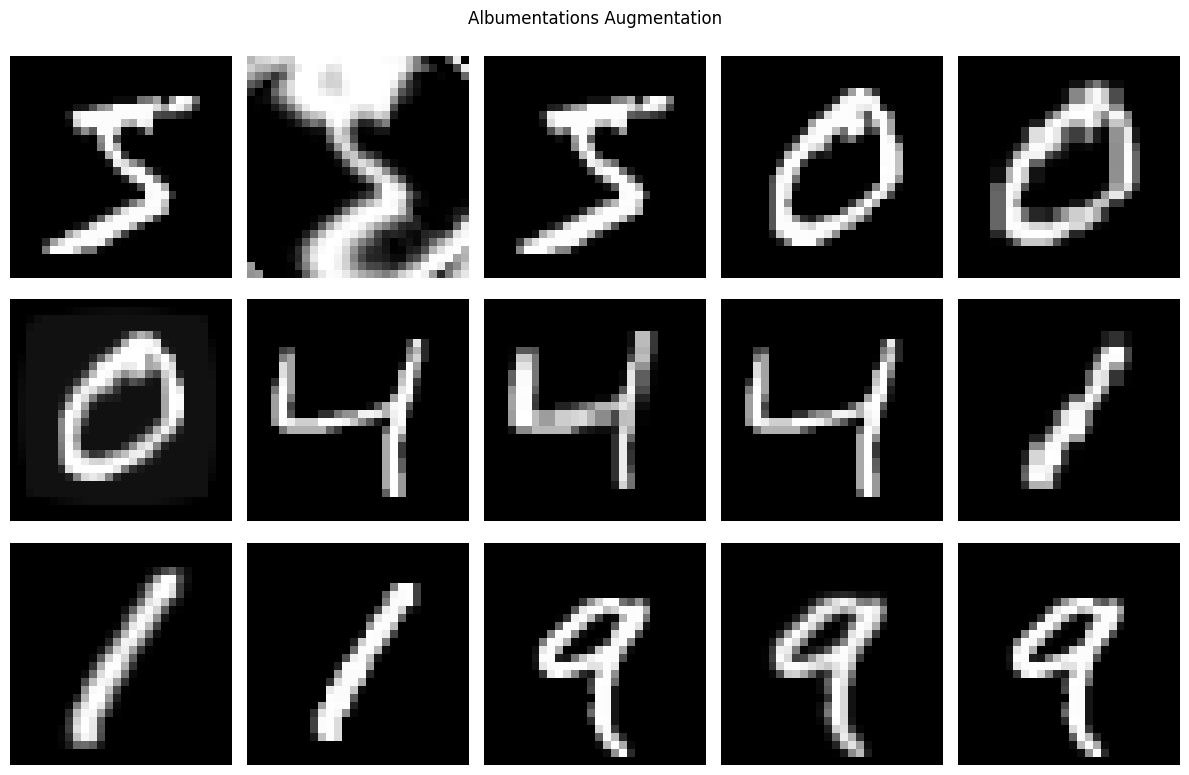

In [127]:
# 7. Image Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator  # :contentReference[oaicite:16]{index=16}
from tensorflow.keras.datasets import mnist

# TODO: Load MNIST, normalize, and reshape to (28,28,1)
#load MNIST
(X_train_img, y_train_img), (X_test_img, y_test_img) = mnist.load_data()

#normalize
X_train_img = X_train_img / 255.0
X_test_img = X_test_img / 255.0

# reshape
X_train_img = X_train_img.reshape(-1,28,28,1)
X_test_img = X_test_img.reshape(-1,28,28,1)

# TODO: Display 5 sample images with true labels
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1, 5, i+1)
  plt.imshow(X_train_img[i].reshape(28, 28), cmap='gray')
  plt.axis('off')
  plt.title(f"Label: {y_train_img[i]}")
plt.tight_layout()
plt.show()
# 7.1 Keras ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10,
                             width_shift_range=0.1,
                             height_shift_range=0.1,
                             zoom_range=0.1,
                             shear_range=0.1,
                             brightness_range=[0.5,1.5],
                             horizontal_flip=True,
                             fill_mode='nearest')
# TODO: Generate and plot 3 augmentations per sample for first 5 images
augmented_images = []
for x_batch in datagen.flow(X_train_img[:5], batch_size= 1, shuffle = False):
  augmented_images.append(x_batch[0])
  if len(augmented_images) >= 15:
    break

# 7.2 tf.image augmentations :contentReference[oaicite:17]{index=17}
import tensorflow as tf
# TODO: Write a function using tf.image.rot90, tf.image.random_brightness, tf.image.random_contrast
def augment_with_tf(image):
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Random rotation
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)

    # Random contrast
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # Ensure values are still between 0 and 1
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image
# 7.3 OpenCV augmentations :contentReference[oaicite:18]{index=18}
import cv2
from scipy import ndimage
import numpy as np

# TODO: Write opencv_augment() that randomly applies rotate, blur, or zoom
def opencv_augment(image):
    # Convert to 0-255 range and uint8 for OpenCV
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Choose a random augmentation
    choice = np.random.choice(['rotate', 'blur', 'zoom', 'original'])

    if choice == 'rotate':
        # Random rotation
        angle = np.random.uniform(-15, 15)
        augmented = ndimage.rotate(image, angle, reshape=False)

    elif choice == 'blur':
        augmented = cv2.GaussianBlur(image, (3, 3), 0)

    elif choice == 'zoom':
        zoom_factor = np.random.uniform(0.8, 1.2)
        height, width = image.shape

        # Compute new dimensions
        new_height = int(height * zoom_factor)
        new_width = int(width * zoom_factor)

        if zoom_factor < 1:  # Zoom out
            # Crop the image
            y_start = (height - new_height) // 2
            x_start = (width - new_width) // 2
            cropped = image[y_start:y_start+new_height, x_start:x_start+new_width]
            # Resize back to original size
            augmented = cv2.resize(cropped, (width, height))
        else:  # Zoom in
            # Resize
            resized = cv2.resize(image, (new_width, new_height))
            # Crop to original size
            y_start = (new_height - height) // 2
            x_start = (new_width - width) // 2
            augmented = resized[y_start:y_start+height, x_start:x_start+width]

    else:
        augmented = image
    augmented = augmented.astype(np.float32) / 255.0
    return augmented.reshape(28, 28, 1)

# 7.4 Albumentations pipeline :contentReference[oaicite:19]{index=19}
import albumentations as A
# TODO: Define A.Compose with RandomBrightnessContrast, ElasticTransform, GridDistortion, OpticalDistortion
def apply_albumentation(image):
    # Convert to 0-255 range and uint8 for Albumentations
    image = (image * 255).astype(np.uint8).reshape(28, 28)

    # Define transformation pipeline
    transform = A.Compose([
        A.OneOf([
            A.RandomBrightnessContrast(p=0.8),
            A.RandomGamma(p=0.8),
        ], p=0.5),
        A.OneOf([
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
            A.GridDistortion(p=0.5),
            A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5),
        ], p=0.5),
    ])

    # Apply transformation
    augmented = transform(image=image)['image']

    # Normalize back to 0-1
    return augmented.astype(np.float32) / 255.0

# Apply Albumentations
albu_augmented = []
for i in range(5):
    # Create 3 augmented versions of each image
    for _ in range(3):
        aug_img = apply_albumentation(X_train_img[i])
        albu_augmented.append(aug_img)

# Display Albumentations augmented images
plt.figure(figsize=(12, 8))
for i, img in enumerate(albu_augmented):
    plt.subplot(3, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle('Albumentations Augmentation')
plt.tight_layout()
plt.show()



In [128]:
# 8. Text Data Augmentation

import random  # :contentReference[oaicite:20]{index=20}

# Sample sentences provided
texts = [
    "This is a great product, I love it!",
    "The service was terrible and I'm disappointed.",
    "I'm not sure how I feel about this experience.",
    "The food was delicious and the staff was friendly.",
    "This movie is boring and too long."
]

# TODO: Implement swap_words(text), delete_random_word(text), insert_random_word(text)

def swap_words(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx1, idx2 = sorted(random.sample(range(len(words)), 2))
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) <= 1:
        return text

    idx = random.randrange(len(words))
    return ' '.join(words[:idx] + words[idx+1:])

def insert_random_word(text, word_list=["really", "very", "somewhat", "quite", "extremely"]):
    words = text.split()
    if not words:
        return text

    idx = random.randrange(len(words))
    word_to_insert = random.choice(word_list)
    return ' '.join(words[:idx] + [word_to_insert] + words[idx:])

# TODO: For each original text, print the 3 augmented variants
augmented_texts = []
for text in texts:
    augmented_texts.append(("Original", text))
    augmented_texts.append(("Word Swap", swap_words(text)))
    augmented_texts.append(("Word Deletion", delete_random_word(text)))
    augmented_texts.append(("Word Insertion", insert_random_word(text)))

# To print 3 augmented variants
for i in range(0, len(augmented_texts), 4):
    print(f"Original: {augmented_texts[i][1]}")
    print(f"  Swap:   {augmented_texts[i+1][1]}")
    print(f"  Delete: {augmented_texts[i+2][1]}")
    print(f"  Insert: {augmented_texts[i+3][1]}")

Original: This is a great product, I love it!
  Swap:   This it! a great product, I love is
  Delete: This is a product, I love it!
  Insert: This is a quite great product, I love it!
Original: The service was terrible and I'm disappointed.
  Swap:   The service was terrible I'm and disappointed.
  Delete: The was terrible and I'm disappointed.
  Insert: really The service was terrible and I'm disappointed.
Original: I'm not sure how I feel about this experience.
  Swap:   this not sure how I feel about I'm experience.
  Delete: I'm not sure how I feel about this
  Insert: extremely I'm not sure how I feel about this experience.
Original: The food was delicious and the staff was friendly.
  Swap:   The friendly. was delicious and the staff was food
  Delete: The was delicious and the staff was friendly.
  Insert: The food really was delicious and the staff was friendly.
Original: This movie is boring and too long.
  Swap:   This long. is boring and too movie
  Delete: This movie is bor

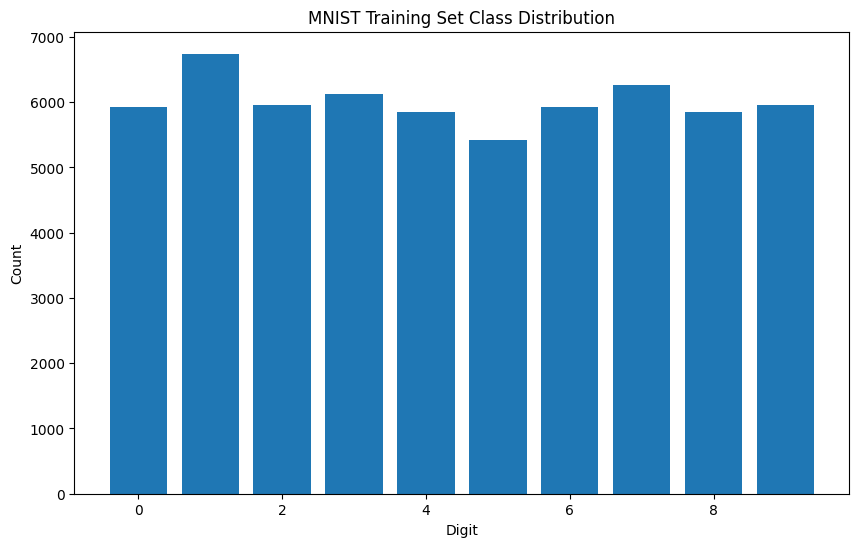

In [129]:
# 9. Class Balancing via Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# TODO: Compute class distribution of y_train_img

unique, counts = np.unique(y_train_img, return_counts=True)
class_distribution = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.bar(class_distribution.keys(), class_distribution.values())
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('MNIST Training Set Class Distribution')
plt.show()

# TODO: Write augment_minority_class(X, y, target_class, num_samples) that:
#         – Finds indices for target_class
#         – Uses ImageDataGenerator.flow to generate until desired count
#         – Returns augmented X_balanced, y_balanced

def augment_minority_class(X, y, target_class, num_samples):
    # Find samples of the target class
    class_indices = np.where(y == target_class)[0]
    X_class = X[class_indices]

    # If we already have enough samples, no need to augment
    if len(X_class) >= num_samples:
        return X, y

    # Number of augmentations needed
    num_augmentations = num_samples - len(X_class)

    # Create augmentation generator
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=False,
        fill_mode='nearest'
    )

    # Generate augmented images
    augmented_images = []
    augmented_labels = []

    for x_batch in datagen.flow(X_class, batch_size=1, shuffle=True):
        augmented_images.append(x_batch[0])
        augmented_labels.append(target_class)
        if len(augmented_images) >= num_augmentations:
            break

    # Convert to numpy arrays
    augmented_images = np.array(augmented_images)
    augmented_labels = np.array(augmented_labels)

    # Combine original and augmented data
    X_balanced = np.vstack([X, augmented_images])
    y_balanced = np.hstack([y, augmented_labels])

    return X_balanced, y_balanced


Imbalanced dataset shape: (920, 28, 28, 1)
Imbalanced labels shape: (920,)
Class distribution:
  Digit 0: 100 samples
  Digit 1: 100 samples
  Digit 2: 100 samples
  Digit 3: 100 samples
  Digit 4: 100 samples
  Digit 5: 100 samples
  Digit 6: 100 samples
  Digit 7: 100 samples
  Digit 8: 20 samples
  Digit 9: 100 samples


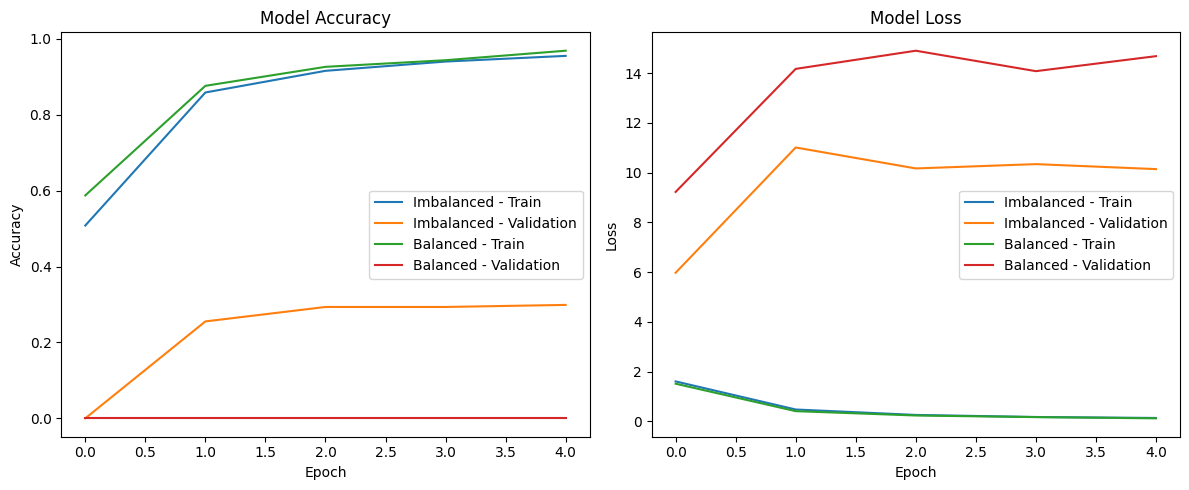


Final Training Accuracies:
Imbalanced Model: 0.9552
Balanced Model:   0.9688

Final Validation Accuracies:
Imbalanced Model: 0.2989
Balanced Model:   0.0000


In [130]:
# 10. Effect of Augmentation on Model Performance

import tensorflow as tf

# TODO: Define create_model() as simple CNN
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Create imbalanced dataset (e.g., first 100 per class minus some for class '8')
def create_imbalanced_dataset(X, y, samples_per_class=100, minority_class=8, minority_samples=20):
    X_imb = []
    y_imb = []

    for digit in range(10):
        # Get indices for this digit
        indices = np.where(y == digit)[0]

        # For minority class, take fewer samples
        if digit == minority_class:
            selected_indices = indices[:minority_samples]
        else:
            selected_indices = indices[:samples_per_class]

        X_imb.append(X[selected_indices])
        y_imb.append(y[selected_indices])

    X_imbalanced = np.vstack(X_imb)
    y_imbalanced = np.hstack(y_imb)

    return X_imbalanced, y_imbalanced

# Create imbalanced dataset
X_imbalanced, y_imbalanced = create_imbalanced_dataset(X_train_img, y_train_img)

print("Imbalanced dataset shape:", X_imbalanced.shape)
print("Imbalanced labels shape:", y_imbalanced.shape)
print("Class distribution:")
unique, counts = np.unique(y_imbalanced, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} samples")

# TODO: Train on imbalanced subset
model_imbalanced = create_model()
history_imbalanced = model_imbalanced.fit(X_imbalanced, y_imbalanced, epochs=5,
                                           validation_split=0.2, verbose=0)

# TODO: Train on balanced data after augmentation
model_balanced = create_model()
history_balanced = model_balanced.fit(X_balanced, y_balanced, epochs=5,
                                       validation_split=0.2, verbose=0)

# TODO: Plot training/validation accuracy and loss side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_imbalanced.history['accuracy'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_accuracy'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['accuracy'], label='Balanced - Train')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced - Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imbalanced.history['loss'], label='Imbalanced - Train')
plt.plot(history_imbalanced.history['val_loss'], label='Imbalanced - Validation')
plt.plot(history_balanced.history['loss'], label='Balanced - Train')
plt.plot(history_balanced.history['val_loss'], label='Balanced - Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Print final accuracies
print("\nFinal Training Accuracies:")
print(f"Imbalanced Model: {history_imbalanced.history['accuracy'][-1]:.4f}")
print(f"Balanced Model:   {history_balanced.history['accuracy'][-1]:.4f}")

print("\nFinal Validation Accuracies:")
print(f"Imbalanced Model: {history_imbalanced.history['val_accuracy'][-1]:.4f}")
print(f"Balanced Model:   {history_balanced.history['val_accuracy'][-1]:.4f}")

**Experiment: feel free to tweak parameters (e.g., k in SelectKBest, PCA components, augmentation ranges) to see their impact.**